In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from all_funcs import *
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from new_grad_descent import CustomGradiendDescent
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')

In [2]:
#загружаем датасет
df = pd.read_csv('podcasts.csv')

In [3]:
#удаляем все пропуски в данных
df = df.dropna(subset=['Listening_Time_minutes', 'Guest_Popularity_percentage', 'Episode_Length_minutes'])

In [4]:
#собираем кат и кол-ые фичи
numeric_features_columns = df.select_dtypes(np.number).columns
cat_features_columns = df.select_dtypes(object).columns
target_column = 'Listening_Time_minutes'

In [5]:
# формируем тестовую, тренировочную выборки
X, y = df.drop(labels=['Listening_Time_minutes'], axis=1), df['Listening_Time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Добавим к базовой линейной модели L1 регуляризацию, чтобы занулить ненужные признаки

In [6]:
param_regularization = {
    'model__alpha': np.logspace(-2, 3, 20)
}
model_lasso = make_pipeline_preprocessor_and_model(num_col=numeric_features_columns,
                                             cat_col=cat_features_columns,
                                             model_class=Lasso)
grid_search_lasso = GridSearchCV(
    estimator=model_lasso,
    param_grid=param_regularization,
    cv=5,  # 5-кратная кросс-валидация
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Параллельные вычисления
    verbose=1,  # Уровень детализации
    return_train_score=True,
)

grid_search_lasso.fit(X_train, y_train)
print("Лучшие параметры:", grid_search_lasso.best_params_)
print("Лучшая оценка (r2):", grid_search_lasso.best_score_)

train_score = grid_search_lasso.score(X_train, y_train)
test_score = grid_search_lasso.score(X_test, y_test)
print(f"\nMSE на обучающей выборке: {train_score:.4f}")
print(f"MSE на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

cross_val_scores = cross_val_score(grid_search_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(cross_val_scores)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Лучшие параметры: {'model__alpha': np.float64(0.03359818286283781)}
Лучшая оценка (r2): -128.01128836445167

MSE на обучающей выборке: -127.8950
MSE на тестовой выборке: -126.5481
Разница (переобучение): -1.3469
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[-11.33401416 -11.27908071 -11.36974703 -11.35984506 -11.23029931]


In [17]:
cross_val_scores.mean()

np.float64(-11.314597255950412)

In [7]:
best_model = grid_search_lasso.best_estimator_
lasso_coef = best_model.named_steps['model'].coef_
feature_names = best_model[:-1].get_feature_names_out()
selected_features = feature_names[lasso_coef != 0]
print(f"Выбрано {len(selected_features)}")
print(selected_features)

Выбрано 11
['num__Episode_Length_minutes' 'num__Host_Popularity_percentage'
 'num__Guest_Popularity_percentage' 'num__Number_of_Ads' 'cat__Genre_News'
 'cat__Genre_Sports' 'cat__Genre_Technology' 'cat__Genre_True Crime'
 'cat__Publication_Time_Evening' 'cat__Episode_Sentiment_Neutral'
 'cat__Episode_Sentiment_Positive']


### Попробуем улучшить предсказания за счет кастомного градиентно спуска и L1 регуляризации 

In [8]:
params_grad = {
    'model__loss': ['mse'],
    'model__learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'model__n_iters': [100, 500, 1000]
}

In [10]:
params_linear_model = {
    'penalty': ['l1'],
    'alpha' : grid_search_lasso.best_params_
}

In [11]:
model_gradient_scale = make_pipeline_preprocessor_and_model(num_col=numeric_features_columns, cat_col=cat_features_columns, model_class=CustomGradiendDescent, scaler=True, params=params_linear_model)

grid_search_for_custom_gd_with_regulariation = GridSearchCV (
    estimator=model_gradient_scale,
    param_grid=params_grad,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)

Подбираем по сетке лучшие параметры для градиентного спуска

In [12]:
grid_search_for_custom_gd_with_regulariation.fit(X_train, y_train)

,estimator,Pipeline(step...lty=['l1']))])
,param_grid,"{'model__learning_rate': [0.1, 0.01, ...], 'model__loss': ['mse'], 'model__n_iters': [100, 500, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [13]:
y_pred = grid_search_for_custom_gd_with_regulariation.predict(X_test)
y_pred_train = grid_search_for_custom_gd_with_regulariation.predict(X_train)
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='TEST')
show_all_regressor_metrics(y_pred=y_pred_train, y_test=y_train, title='TRAIN')

=============================TEST========================================
R2 - 0.8284680853218759
MSE - 127.18675486596098
RMSE - 11.277710532992101
=============================TRAIN========================================
R2 - 0.8276505609932557
MSE - 127.29780643032505
RMSE - 11.28263295646566


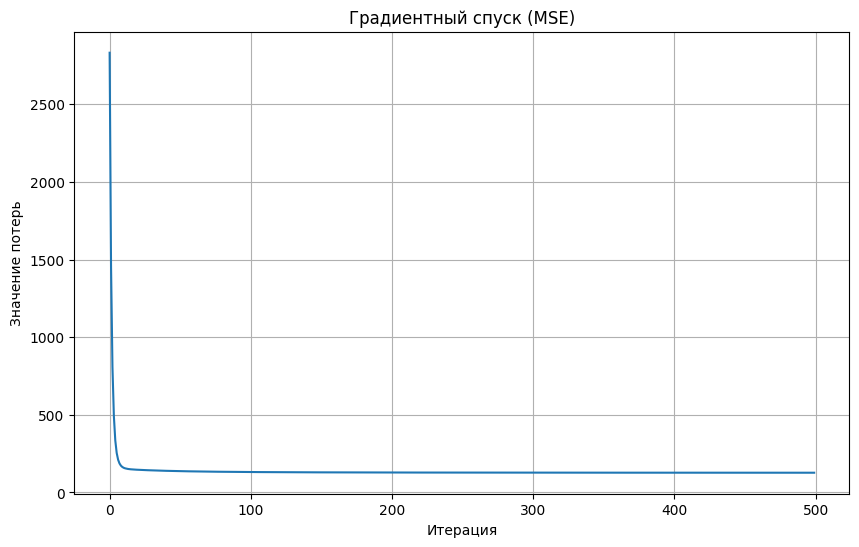

Лучшие параметры: {'model__learning_rate': 0.1, 'model__loss': 'mse', 'model__n_iters': 500}
Лучшая оценка MSE: -128.63557220716595

MSE на обучающей выборке: -127.2978
MSE на тестовой выборке: -127.1868
Разница (переобучение): -0.1111


In [14]:
grid_search_for_custom_gd_with_regulariation.best_estimator_['model'].plot_loss()

print("Лучшие параметры:", grid_search_for_custom_gd_with_regulariation.best_params_)
print("Лучшая оценка MSE:", grid_search_for_custom_gd_with_regulariation.best_score_)

train_score = grid_search_for_custom_gd_with_regulariation.score(X_train, y_train)
test_score = grid_search_for_custom_gd_with_regulariation.score(X_test, y_test)
print(f"\nMSE на обучающей выборке: {train_score:.4f}")
print(f"MSE на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

Градиентый спуск  выходит на плато уже на первой сотне итераций. Посмотрим устойчивость модели с помощью кросс-валидации

In [15]:
score = cross_val_score(grid_search_for_custom_gd_with_regulariation.best_estimator_, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(score)

[-11.3601855  -11.29148645 -11.39126985 -11.39264119 -11.27266953]


In [16]:
score.mean()

np.float64(-11.341650502050198)

### Модель стабильна, разброс на всех фолдах минимальный, но качество не улучшается. 

### Обучим случайный лес c дефолтными гиперпараметрами

In [75]:
from sklearn.ensemble import RandomForestRegressor

In [76]:
random_forest = make_pipeline_preprocessor_and_model(num_col=numeric_features_columns, cat_col=cat_features_columns, model_class=RandomForestRegressor)

In [77]:
random_forest.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
y_pred = random_forest.predict(X_test)

In [79]:
y_train_pred = random_forest.predict(X_train)

In [80]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test)

R2 - 0.8310814838701448
MSE - 125.24898322066997
RMSE - 11.191469216357161


In [81]:
show_all_regressor_metrics(y_pred=y_train_pred, y_test=y_train)

R2 - 0.9763046650622996
MSE - 17.501444609187622
RMSE - 4.1834727929302495


#### Модель сильно переобучена. Подберем параметры по сетке

Сформируем пайплайн для предобработки данных

In [82]:
model_random_forest = make_pipeline_preprocessor_and_model(num_col=numeric_features_columns, cat_col=cat_features_columns, model_class=RandomForestRegressor)

In [87]:
param_grid_tree = {
    'model__n_estimators': [5, 10, 15],
    # 'model__max_depth':  [3, 5, 10, 20, 50, 90],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt'],
    'model__bootstrap': [True]
}

In [88]:
tree_grid_search_ = GridSearchCV(
    estimator=model_random_forest,
    param_grid=param_grid_tree,
    cv=5,  # 5-кратная кросс-валидация
    scoring='r2',
    n_jobs=-1,  # Параллельные вычисления
    verbose=1,  # Уровень детализации
    return_train_score=True,
)

In [89]:
tree_grid_search_.fit(X_train, y_train)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


/Users/poltava/Desktop/ML_practice/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
135 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/poltava/Desktop/ML_practice/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/poltava/Desktop/ML_practice/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/poltava/Desktop/ML_pr

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__bootstrap': [True], 'model__max_features': ['auto', 'sqrt'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [86]:
print("Лучшие параметры:", tree_grid_search_.best_params_)
print("Лучшая оценка (r2):", tree_grid_search_.best_score_)

train_score = tree_grid_search_.score(X_train, y_train)
test_score = tree_grid_search_.score(X_test, y_test)
print(f"\nR² на обучающей выборке: {train_score:.4f}")
print(f"R² на тестовой выборке: {test_score:.4f}")
print(f"Разница (переобучение): {train_score - test_score:.4f}")

Лучшие параметры: {'model__bootstrap': True, 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 15}
Лучшая оценка (r2): 0.732142092973423

R² на обучающей выборке: 0.7418
R² на тестовой выборке: 0.7041
Разница (переобучение): 0.0377
